In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_ml = pd.read_csv('credit_risk_data_optimized.csv')
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_ID                  32581 non-null  str    
 1   person_age                 32581 non-null  int64  
 2   person_income              32581 non-null  int64  
 3   person_home_ownership      32581 non-null  str    
 4   person_emp_length          32581 non-null  float64
 5   loan_intent                32581 non-null  str    
 6   loan_grade                 32581 non-null  str    
 7   loan_amnt                  32581 non-null  int64  
 8   loan_int_rate              32581 non-null  float64
 9   loan_status                32581 non-null  int64  
 10  loan_percent_income        32581 non-null  float64
 11  cb_person_default_on_file  32581 non-null  str    
 12  gender                     32581 non-null  str    
 13  marital_status             32581 non-null  str    
 14  e

In [2]:
X = df_ml.drop(columns=['client_ID', 'loan_status', 'person_age', 'age_group_raw', 'credit_history_group_raw','city_latitude', 'city', 'state'])
y = df_ml['loan_status']

categorical_cols = X.select_dtypes(include=['str']).columns
print("Categorical columns:", categorical_cols)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"- Đã mã hóa các cột dạng chữ. Số lượng features hiện tại: {X_encoded.shape[1]}")

Categorical columns: Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file', 'gender', 'marital_status',
       'education_level', 'country', 'employment_type', 'age_group',
       'credit_history_group'],
      dtype='str')
- Đã mã hóa các cột dạng chữ. Số lượng features hiện tại: 44


In [3]:
X_encoded.head()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,city_longitude,loan_term_months,open_accounts,credit_utilization_ratio,past_delinquencies,...,country_USA,employment_type_Part-time,employment_type_Self-employed,employment_type_Unemployed,age_group_23-26,age_group_26-30,age_group_30+,credit_history_group_Ngắn,credit_history_group_Rất dài,credit_history_group_Trung bình
0,59000,123.0,35000,16.02,0.59,-79.3832,36,14,0.495557,0,...,False,False,True,False,False,False,False,True,False,False
1,9600,5.0,1000,11.14,0.10,-79.3832,36,10,0.585436,3,...,False,False,False,False,False,False,False,True,False,False
2,9600,1.0,5500,12.87,0.57,-3.9436,36,14,0.750732,0,...,False,False,False,False,True,False,False,True,False,False
3,65500,4.0,35000,15.23,0.53,-123.1207,12,15,0.379333,0,...,False,True,False,False,False,False,False,True,False,False
4,54400,8.0,35000,14.27,0.55,-78.8784,36,4,0.228103,0,...,True,True,False,False,True,False,False,False,False,True


In [4]:
print("--- SPLIT DATASET ---")
# 15% làm tập Test, 85% làm tập Temp
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42, stratify=y
)

# Từ 85% tập Temp, cắt tiếp lấy 15% làm Valid, 70% làm Train
valid_ratio = 0.15 / 0.85 
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=valid_ratio, random_state=42, stratify=y_temp
)

print(f"Sample size - Train: {X_train_raw.shape[0]} | Valid: {X_valid_raw.shape[0]} | Test: {X_test_raw.shape[0]}")

--- SPLIT DATASET ---
Sample size - Train: 22806 | Valid: 4887 | Test: 4888


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15464\2903153486.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.head(20).values, y=rf_importances.head(20).index, palette='viridis')


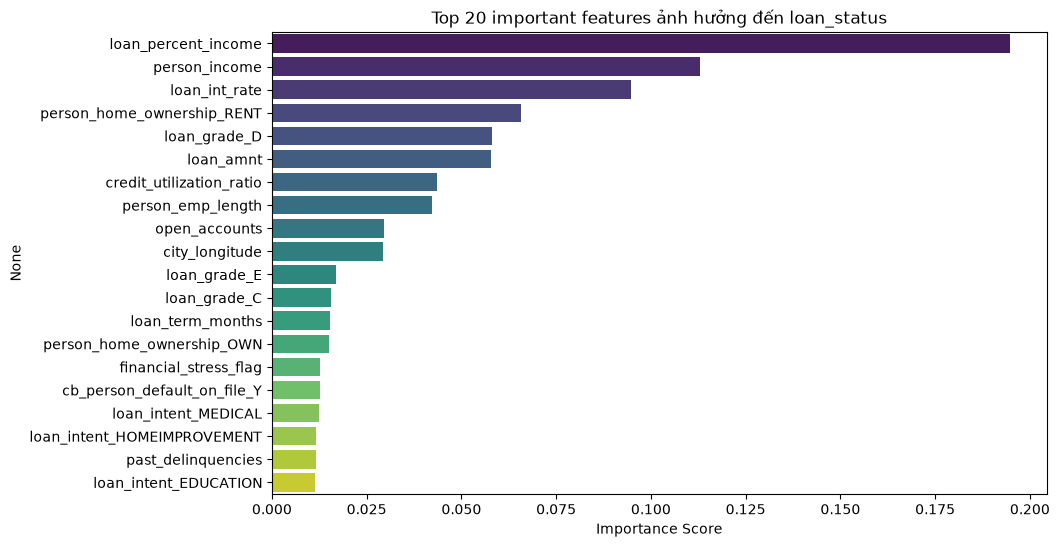


 List 20 important features được giữ lại:
['loan_percent_income', 'person_income', 'loan_int_rate', 'person_home_ownership_RENT', 'loan_grade_D', 'loan_amnt', 'credit_utilization_ratio', 'person_emp_length', 'open_accounts', 'city_longitude', 'loan_grade_E', 'loan_grade_C', 'loan_term_months', 'person_home_ownership_OWN', 'financial_stress_flag', 'cb_person_default_on_file_Y', 'loan_intent_MEDICAL', 'loan_intent_HOMEIMPROVEMENT', 'past_delinquencies', 'loan_intent_EDUCATION']


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
from matplotlib import pyplot as plt

# Huấn luyện mô hình Random Forest để tìm Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_raw, y_train)

# Trích xuất và sắp xếp mức độ quan trọng
importances = rf.feature_importances_
feature_names = X_train_raw.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Trực quan hóa Top các Feature quan trọng nhất
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.head(20).values, y=rf_importances.head(20).index, palette='viridis')
plt.title('Top 20 important features ảnh hưởng đến loan_status')
plt.xlabel('Importance Score')
plt.show()

# 4. Lựa chọn 20 Feature giữ lại dựa trên ngưỡng hoặc số lượng cố định
top_features = rf_importances.head(20).index.tolist()
print(f"\n List 20 important features được giữ lại:\n{top_features}")

In [6]:
X_train = X_train_raw[top_features].copy()
X_valid = X_valid_raw[top_features].copy()
X_test = X_test_raw[top_features].copy()

--- KIỂM TRA VÀ XỬ LÝ OUTLIERS (IQR CAPPING) ---
 'loan_percent_income': Phát hiện 468 outliers trên tập Train.


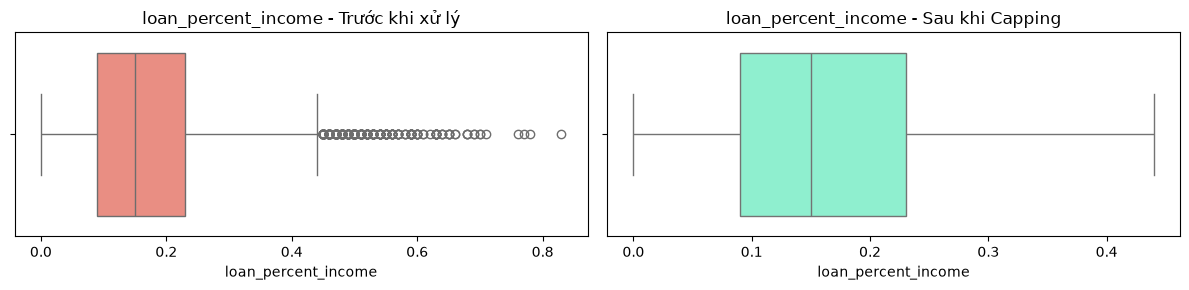

 'person_income': Phát hiện 1122 outliers trên tập Train.


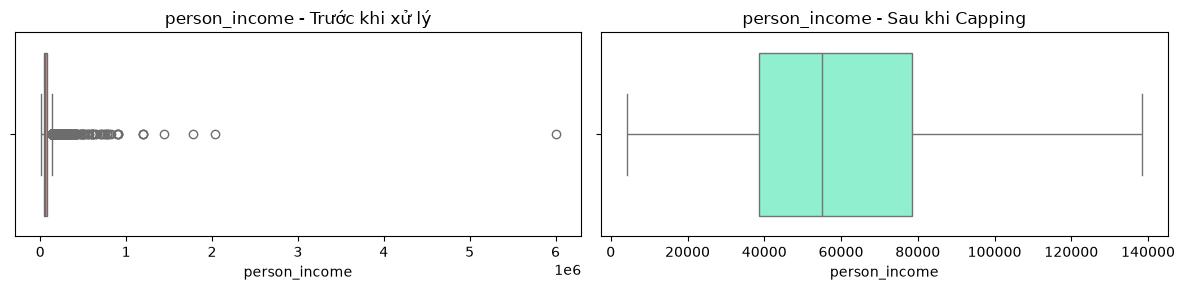

 'loan_int_rate': Phát hiện 45 outliers trên tập Train.


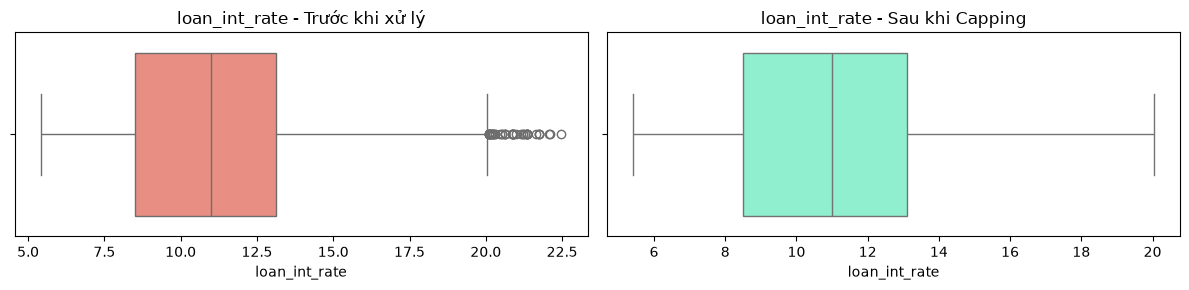

 'loan_amnt': Phát hiện 1216 outliers trên tập Train.


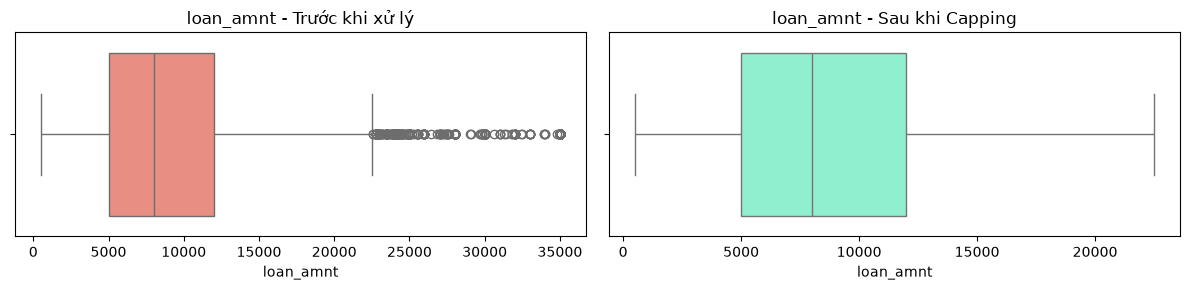

 'credit_utilization_ratio': Phát hiện 0 outliers trên tập Train.
-> 'credit_utilization_ratio' không có outliers, giữ nguyên.
 'person_emp_length': Phát hiện 604 outliers trên tập Train.


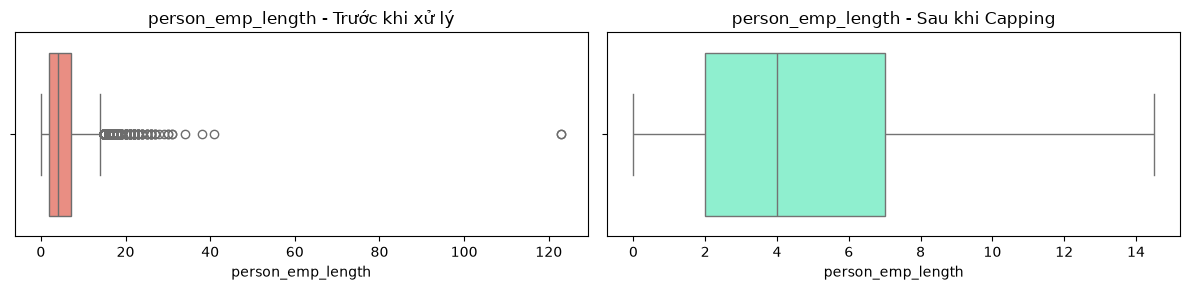

 'open_accounts': Phát hiện 0 outliers trên tập Train.
-> 'open_accounts' không có outliers, giữ nguyên.
 'city_longitude': Phát hiện 0 outliers trên tập Train.
-> 'city_longitude' không có outliers, giữ nguyên.
 'loan_term_months': Phát hiện 0 outliers trên tập Train.
-> 'loan_term_months' không có outliers, giữ nguyên.
 'financial_stress_flag': Phát hiện 0 outliers trên tập Train.
-> 'financial_stress_flag' không có outliers, giữ nguyên.
 'past_delinquencies': Phát hiện 330 outliers trên tập Train.


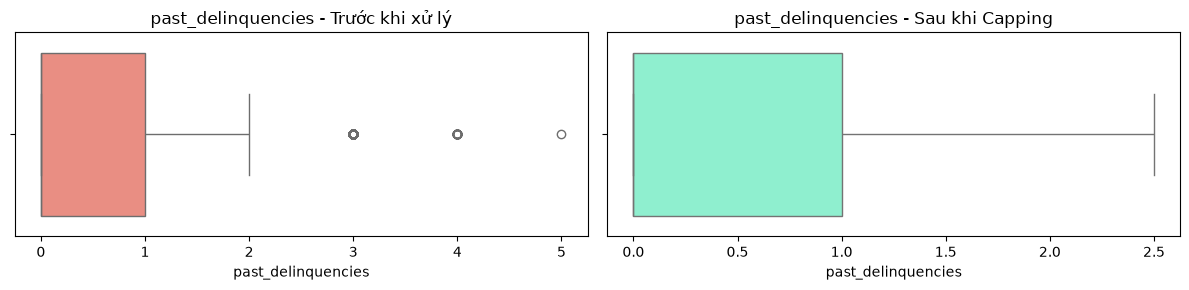

In [7]:
import numpy as np
print("--- KIỂM TRA VÀ XỬ LÝ OUTLIERS (IQR CAPPING) ---")
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
outlier_thresholds = {}

for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_thresholds[col] = {'lower': lower_bound, 'upper': upper_bound}
    
    # Thống kê số lượng outliers trên tập Train trước khi xử lý
    train_outliers = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()
    print(f" '{col}': Phát hiện {train_outliers} outliers trên tập Train.")
    
    if train_outliers > 0:
        # Trực quan hóa phân bố TRƯỚC và SAU khi xử lý Outlier
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        sns.boxplot(x=X_train[col], ax=axes[0], color='salmon')
        axes[0].set_title(f'{col} - Trước khi xử lý')
        
        # Tiến hành Capping (Giới hạn biên) trên cả 3 tập dựa theo ngưỡng của tập Train
        X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
        X_valid[col] = np.clip(X_valid[col], lower_bound, upper_bound)
        X_test[col]  = np.clip(X_test[col], lower_bound, upper_bound)
        
        sns.boxplot(x=X_train[col], ax=axes[1], color='aquamarine')
        axes[1].set_title(f'{col} - Sau khi Capping')
        plt.tight_layout()
        plt.show()
    else:
        print(f"-> '{col}' không có outliers, giữ nguyên.")

--- KIỂM TRA PHÂN PHỐI VÀ POWER TRANSFORMATION ---
 'loan_percent_income' có điểm Skewness: 0.82
 'person_income' có điểm Skewness: 0.86
 'loan_int_rate' có điểm Skewness: 0.20
 'loan_amnt' có điểm Skewness: 0.77
 'credit_utilization_ratio' có điểm Skewness: -0.01
 'person_emp_length' có điểm Skewness: 0.84
 'open_accounts' có điểm Skewness: -0.00
 'city_longitude' có điểm Skewness: 0.29
 'loan_term_months' có điểm Skewness: 0.13
 'financial_stress_flag' có điểm Skewness: -0.33
 'past_delinquencies' có điểm Skewness: 1.11

-> Phát hiện các cột bị lệch nặng cần xử lý biến đổi: ['past_delinquencies']


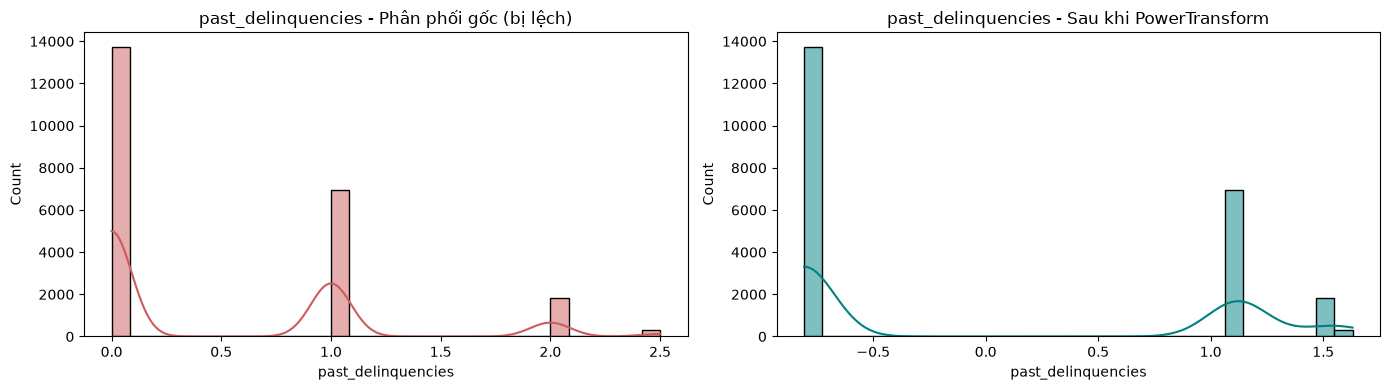


 Kiểm tra lại điểm Skewness của các cột sau khi biến đổi:
 - 'past_delinquencies': 0.46 (Đã tối ưu hóa sát mức 0)

 StandardScaler cho các cột không lệch: ['loan_percent_income', 'person_income', 'loan_int_rate', 'loan_amnt', 'credit_utilization_ratio', 'person_emp_length', 'open_accounts', 'city_longitude', 'loan_term_months', 'financial_stress_flag']


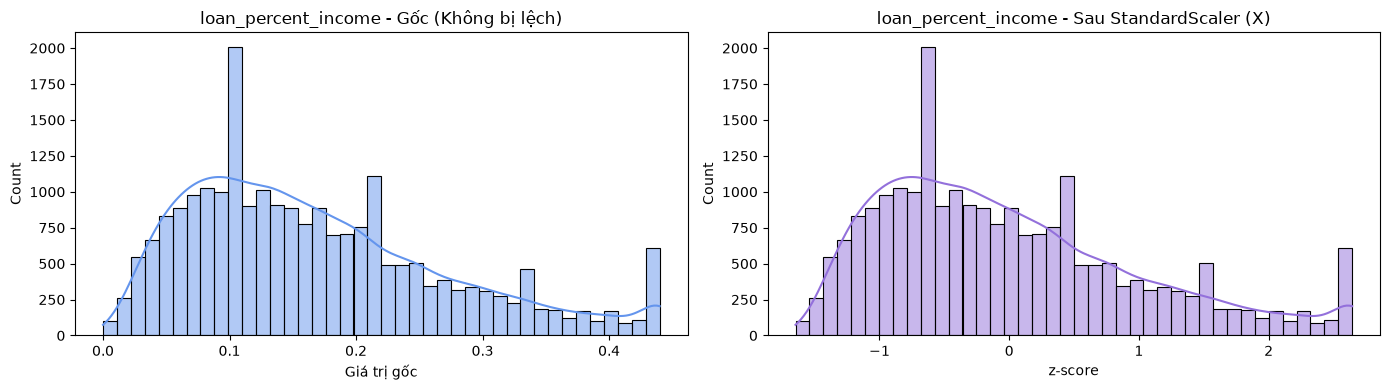

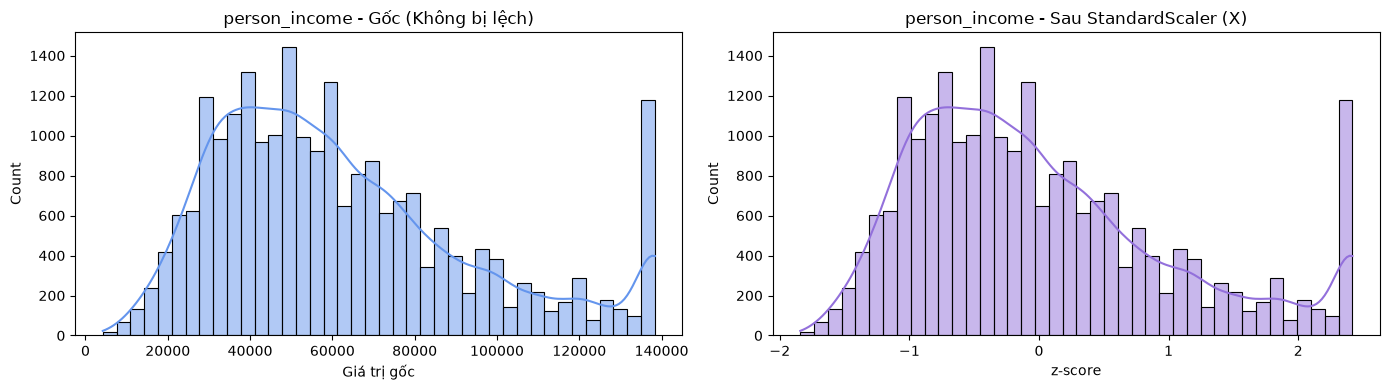

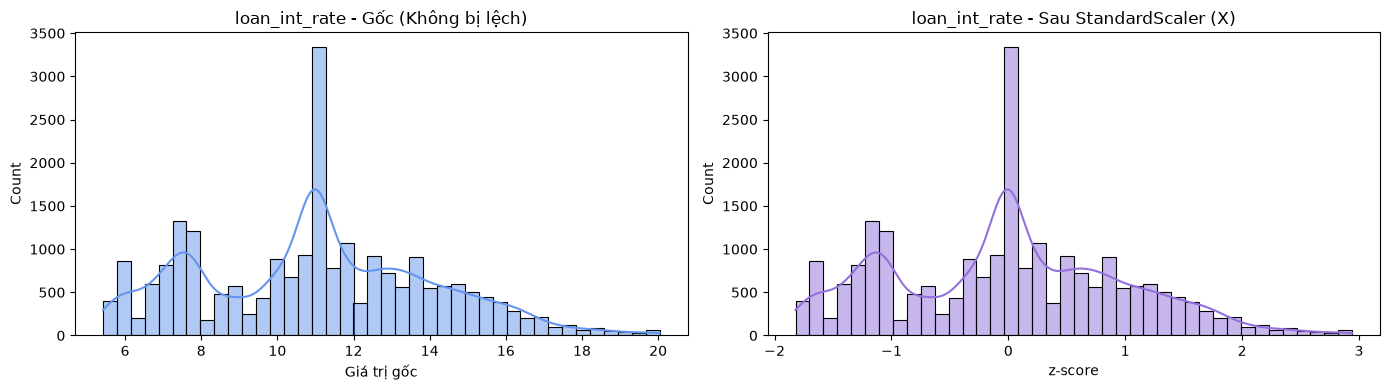

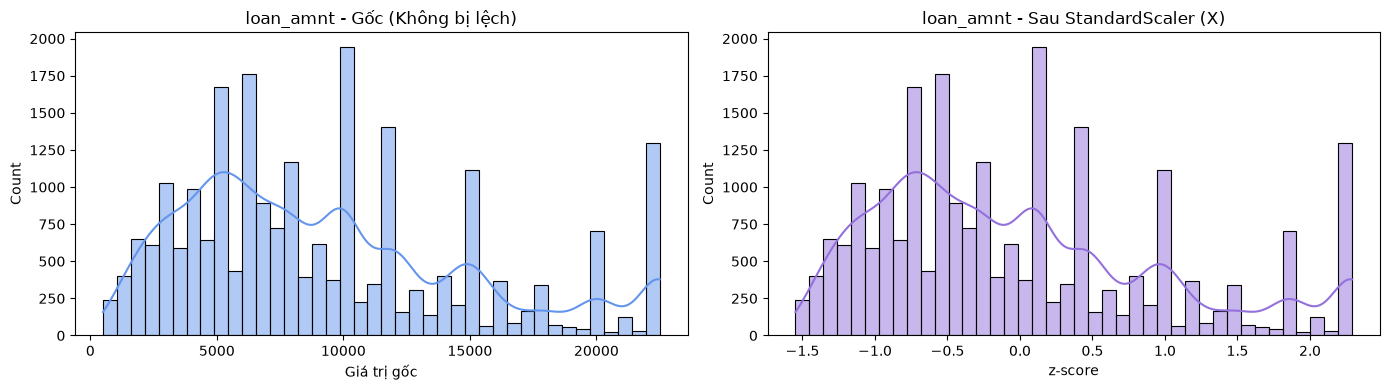

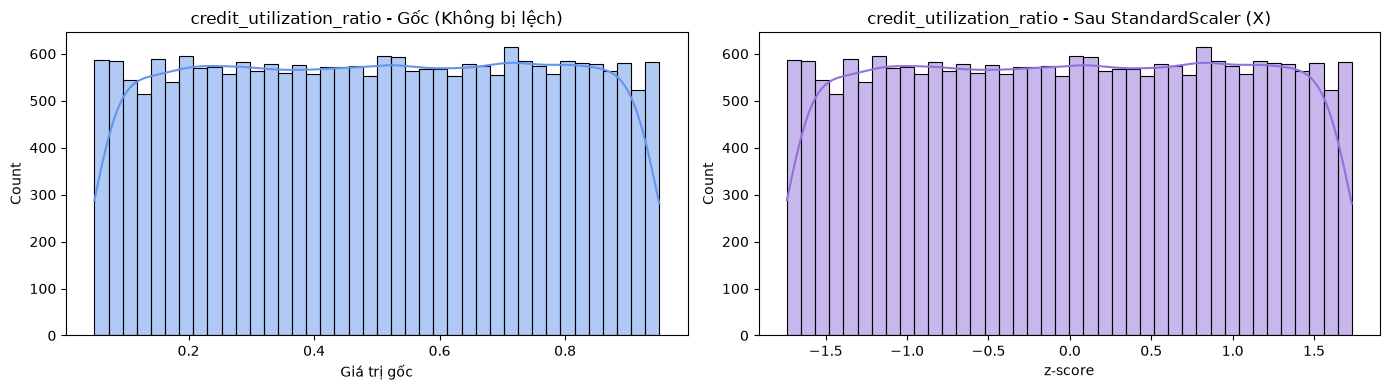

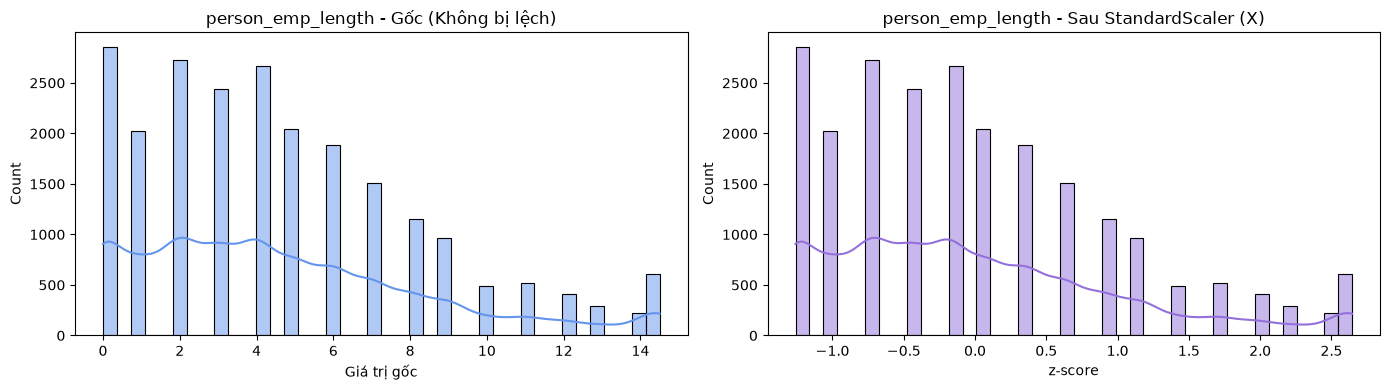

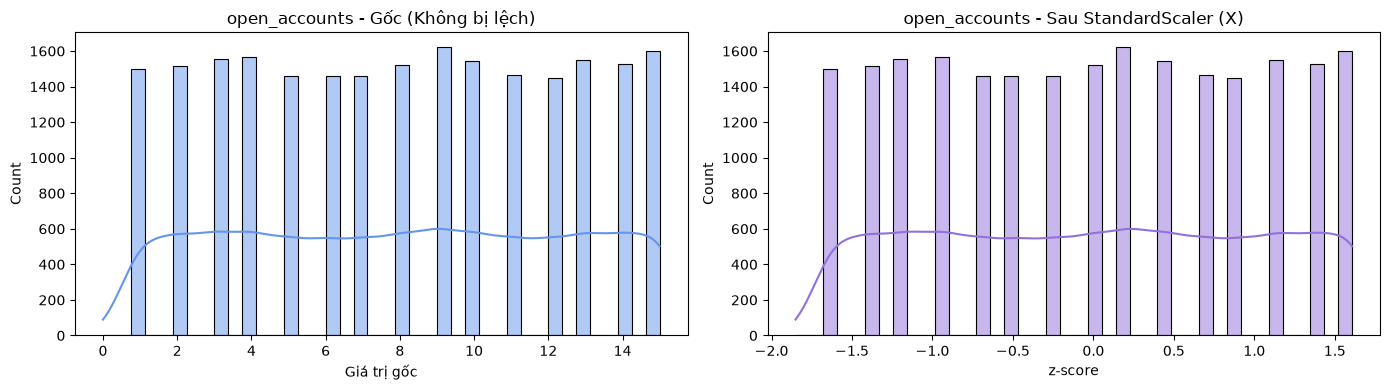

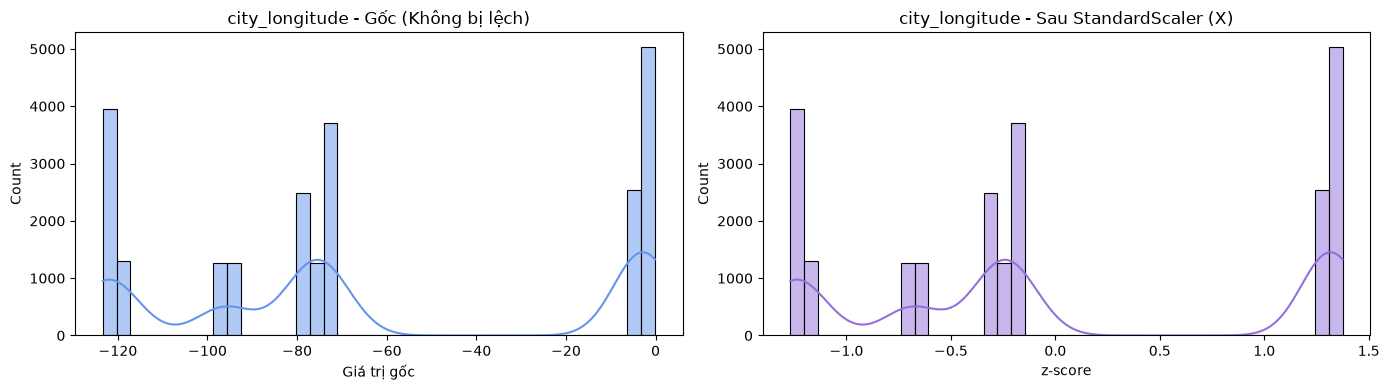

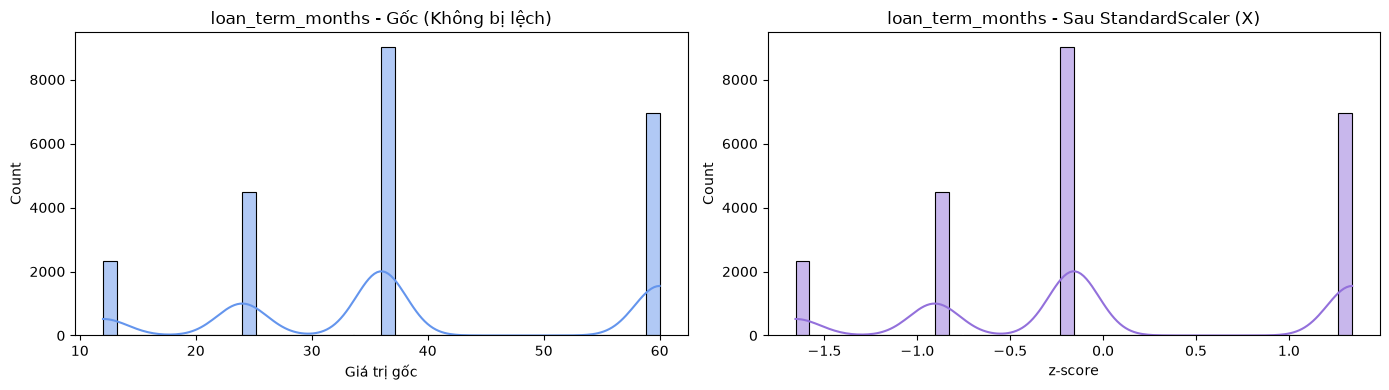

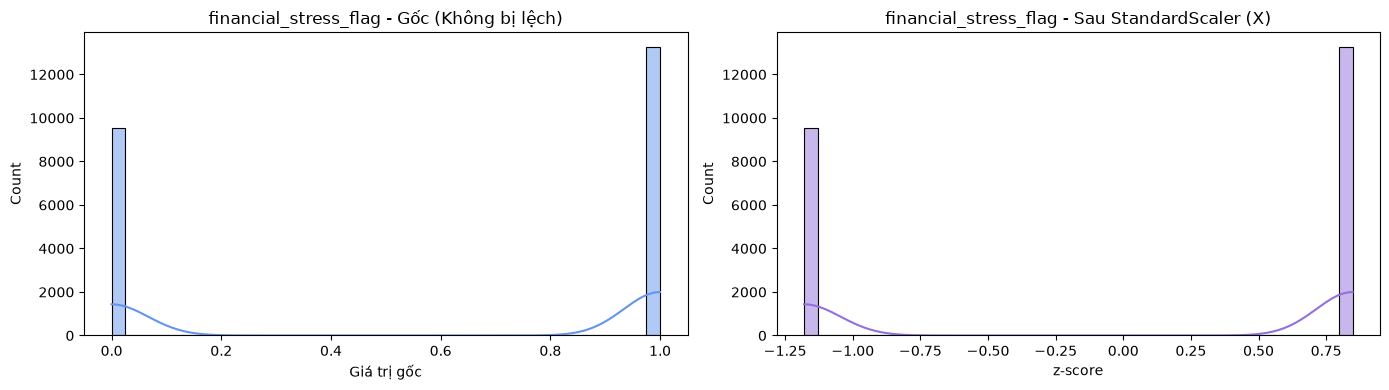

In [8]:
from sklearn.preprocessing import PowerTransformer

print("--- KIỂM TRA PHÂN PHỐI VÀ POWER TRANSFORMATION ---")

threshold_skew = 1.0
pt = PowerTransformer(method='yeo-johnson', standardize=True)

cols_to_transform = []
X_train_before = X_train.copy()

for col in numeric_cols:
    # Tính điểm skew trên tập Train
    current_skew = X_train[col].skew()
    print(f" '{col}' có điểm Skewness: {current_skew:.2f}")
    
    if abs(current_skew) > threshold_skew:
        cols_to_transform.append(col)

if len(cols_to_transform) > 0:
    print(f"\n-> Phát hiện các cột bị lệch nặng cần xử lý biến đổi: {cols_to_transform}")
    
    # Trực quan hóa phân phối của cột đầu tiên bị lệch làm mẫu đối chứng
    sample_col = cols_to_transform[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(X_train[sample_col], bins=30, kde=True, ax=axes[0], color='indianred')
    axes[0].set_title(f'{sample_col} - Phân phối gốc (bị lệch)')
    
    # HỌC công thức phân phối trên tập Train và BIẾN ĐỔI dữ liệu
    X_train[cols_to_transform] = pt.fit_transform(X_train[cols_to_transform])
    
    # ÁP DỤNG công thức đã học lên tập Valid và Test (Tuyệt đối không fit lại)
    X_valid[cols_to_transform] = pt.transform(X_valid[cols_to_transform])
    X_test[cols_to_transform]  = pt.transform(X_test[cols_to_transform])
    
    sns.histplot(X_train[sample_col], bins=30, kde=True, ax=axes[1], color='teal')
    axes[1].set_title(f'{sample_col} - Sau khi PowerTransform')
    plt.tight_layout()
    plt.show()
    
    print("\n Kiểm tra lại điểm Skewness của các cột sau khi biến đổi:")
    for col in cols_to_transform:
        print(f" - '{col}': {X_train[col].skew():.2f} (Đã tối ưu hóa sát mức 0)")
else:
    print("\n Không có feature nào bị lệch phân phối vượt ngưỡng.")

# Đối với các cột số còn lại KHÔNG cần biến đổi hình học, ta vẫn phải chuẩn hóa thang đo bằng StandardScaler
from sklearn.preprocessing import StandardScaler
remaining_numeric_cols = [c for c in numeric_cols if c not in cols_to_transform]

if len(remaining_numeric_cols) > 0:
    scaler = StandardScaler()
    X_train[remaining_numeric_cols] = scaler.fit_transform(X_train[remaining_numeric_cols])
    X_valid[remaining_numeric_cols] = scaler.transform(X_valid[remaining_numeric_cols])
    X_test[remaining_numeric_cols]  = scaler.transform(X_test[remaining_numeric_cols])
    print(f"\n StandardScaler cho các cột không lệch: {remaining_numeric_cols}")

for col in remaining_numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # Biểu đồ gốc
        sns.histplot(X_train_before[col], bins=40, kde=True, ax=axes[0], color='cornflowerblue')
        axes[0].set_title(f'{col} - Gốc (Không bị lệch)')
        axes[0].set_xlabel('Giá trị gốc')
        
        # Biểu đồ sau chuẩn hóa
        sns.histplot(X_train[col], bins=40, kde=True, ax=axes[1], color='mediumpurple')
        axes[1].set_title(f'{col} - Sau StandardScaler (X)')
        axes[1].set_xlabel('z-score')
        
        plt.tight_layout()
        plt.show()
# for col in numeric_top_features:
#     # Tính toán độ lệch ban đầu
#     skew_score = X_train[col].skew()
#     print(f"\nĐặc trưng '{col}' có độ lệch ban đầu: {skew_score:.2f}")
    
#     # Nếu độ lệch vượt ngưỡng, tiến hành vẽ biểu đồ và biến đổi Log
#     if abs(skew_score) > threshold_skew:
#         print(f"-> Nhận diện '{col}' bị lệch phân phối. Tiến hành biến đổi Log và trực quan hóa...")
        
#         # Khởi tạo khung vẽ biểu đồ Trước và Sau
#         fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
#         # Biểu đồ TRƯỚC khi biến đổi
#         sns.histplot(X_train[col], bins=40, kde=True, ax=axes[0], color='indianred')
#         axes[0].set_title(f'{col} - Trước biến đổi (Lệch)')
#         axes[0].set_xlabel('Giá trị gốc')
        
#         # Thực hiện biến đổi Logarit (Dùng log1p để an toàn với giá trị số 0)
#         X_train[col + '_log'] = np.log1p(X_train[col])
#         X_test[col + '_log'] = np.log1p(X_test[col])
        
#         # Biểu đồ sau khi biến đổi
#         sns.histplot(X_train[col + '_log'], bins=40, kde=True, ax=axes[1], color='teal')
#         axes[1].set_title(f'{col} - Sau biến đổi Log')
#         axes[1].set_xlabel('Giá trị sau khi Log')
        
#         plt.tight_layout()
#         plt.show()
        
#         # Xóa cột dữ liệu gốc cũ đi để tránh trùng lặp thông tin
#         X_train = X_train.drop(columns=[col])
#         X_test = X_test.drop(columns=[col])
#     else:
#         print(f"-> Phân phối của '{col}' tương đối ổn định, giữ nguyên không cần biến đổi Log.")

--- PHÂN BỐ DỮ LIỆU BIẾN MỤC TIÊU ---
Số lượng Trả đủ (0): 25473 (78.18%)
Số lượng Nợ xấu (1): 7108 (21.82%)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15464\3054054473.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set1')


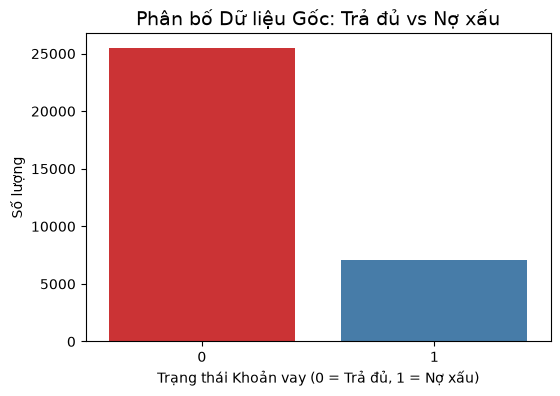


--- SMOTE ĐỂ CÂN BẰNG TẬP TRAIN ---
Phân bố tập TRAIN trước khi cân bằng:
loan_status
0    17830
1     4976
Name: count, dtype: int64

Phân bố tập TRAIN sau khi dùng SMOTE:
loan_status
1    17830
0    17830
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15464\3054054473.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set2', ax=ax[0]).set_title("Tập Train cũ (imbalanced)")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15464\3054054473.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced, palette='Set2', ax=ax[1]).set_title("Tập Train mới (balanced)")


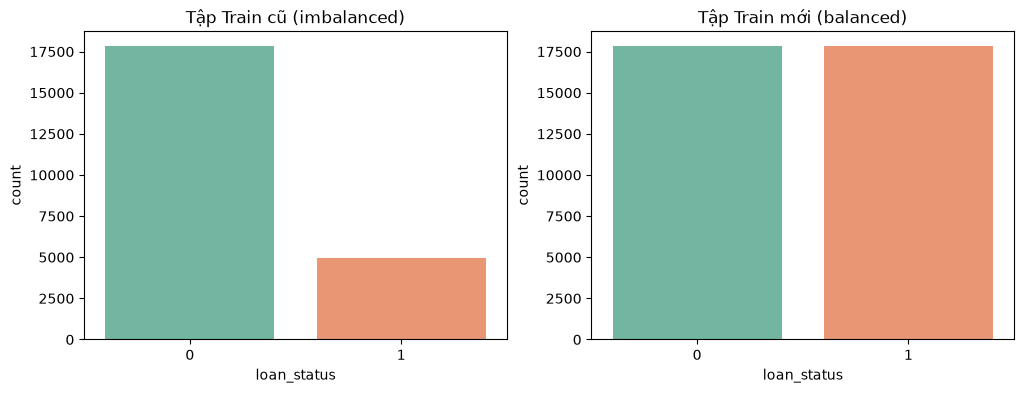

In [9]:
from imblearn.over_sampling import SMOTE

print("--- PHÂN BỐ DỮ LIỆU BIẾN MỤC TIÊU ---")
original_counts = y.value_counts()
original_percentages = y.value_counts(normalize=True) * 100

print(f"Số lượng Trả đủ (0): {original_counts[0]} ({original_percentages[0]:.2f}%)")
print(f"Số lượng Nợ xấu (1): {original_counts[1]} ({original_percentages[1]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set1')
plt.title('Phân bố Dữ liệu Gốc: Trả đủ vs Nợ xấu', fontsize=14)
plt.xlabel('Trạng thái Khoản vay (0 = Trả đủ, 1 = Nợ xấu)')
plt.ylabel('Số lượng')
plt.show()

print("\n--- SMOTE ĐỂ CÂN BẰNG TẬP TRAIN ---")

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Kiểm tra lại kết quả sau khi dùng SMOTE
print("Phân bố tập TRAIN trước khi cân bằng:")
print(y_train.value_counts())

print("\nPhân bố tập TRAIN sau khi dùng SMOTE:")
print(y_train_balanced.value_counts())

# Vẽ biểu đồ so sánh trên tập Train
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, palette='Set2', ax=ax[0]).set_title("Tập Train cũ (imbalanced)")
sns.countplot(x=y_train_balanced, palette='Set2', ax=ax[1]).set_title("Tập Train mới (balanced)")
plt.show()

In [10]:
X_train_balanced.to_csv('processed_data/X_train_final.csv', index=False)
y_train_balanced.to_csv('processed_data/y_train_final.csv', index=False)
X_valid.to_csv('processed_data/X_valid_final.csv', index=False)
y_valid.to_csv('processed_data/y_valid_final.csv', index=False)
X_test.to_csv('processed_data/X_test_final.csv', index=False)
y_test.to_csv('processed_data/y_test_final.csv', index=False)